# Deutsch-Jozsa Algorithm — Conceptual Understanding

## 1. What is the input/output structure of the function f?

In the Deutsch-Jozsa algorithm, the function:

\[
f(x): \{0,1\}^n \rightarrow \{0,1\}
\]

takes an input of **n classical bits** and produces **1 output bit**.

For example, if \( n = 3 \):

\[
x \in \{000,001,010,011,100,101,110,111\}
\]

and the function outputs either 0 or 1 for each input.

So the function behaves like a black-box oracle that maps:

\[
n\text{-bit input} \rightarrow 1\text{-bit output}
\]

---

## 2. What does “constant” mean? What does “balanced” mean?

### Constant Function
A function is **constant** if it gives the same output for every possible input.

Examples:

\[
f(x)=0 \quad \text{for all } x
\]

or

\[
f(x)=1 \quad \text{for all } x
\]

No matter what input is given, the output never changes.

---

### Balanced Function
A function is **balanced** if:

- half of the inputs produce 0
- half of the inputs produce 1

Example for 2-bit input:

| Input | Output |
|---|---|
| 00 | 0 |
| 01 | 0 |
| 10 | 1 |
| 11 | 1 |

Exactly half the outputs are 0 and half are 1.

---

## 3. Classical worst case: how many queries are needed?

Classically, to be completely certain a function is constant, we may need:

\[
2^{n-1}+1
\]

queries in the worst case.

Why?

Because after checking \(2^{n-1}\) inputs, all outputs could still be identical, and the next unseen input might finally differ.

Example:

If \(n=3\):

\[
2^{3-1}+1 = 5
\]

So a classical computer may need up to 5 oracle evaluations.

---

## 4. Why does Deutsch-Jozsa need only one quantum query?

The Deutsch-Jozsa algorithm uses:

- quantum superposition
- phase kickback
- quantum interference

to evaluate all possible inputs simultaneously in one oracle call.

Instead of testing one input at a time, the quantum circuit places all input states into superposition:

\[
\frac{1}{\sqrt{2^n}} \sum_x |x\rangle
\]

The oracle processes all states at once, and interference after the final Hadamard gates reveals whether the function is constant or balanced.

So the algorithm determines a global property of the function using only a single quantum query.

---

## 5. What is phase kickback, and why does the ancilla qubit start in the \(|-\rangle\) state?

The ancilla qubit is initialized as:

\[
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
\]

This special state allows the oracle to encode information into the **phase** of the quantum state instead of directly storing the function output in a qubit.

When the oracle computes:

\[
f(x)
\]

the effect becomes:

\[
|x\rangle \rightarrow (-1)^{f(x)}|x\rangle
\]

This is called **phase kickback**.

Instead of changing measurement values directly, the oracle changes the sign (phase) of amplitudes.

These phase differences later interfere constructively or destructively after the final Hadamard gates, allowing the algorithm to distinguish constant and balanced functions.

The ancilla qubit starts in the \(|-\rangle\) state specifically because it enables this phase encoding behavior.

In [1]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile
from quantum_qr.dj import dj_circuit, const_oracle_zero, const_oracle_one


In [2]:
simulator = AerSimulator()

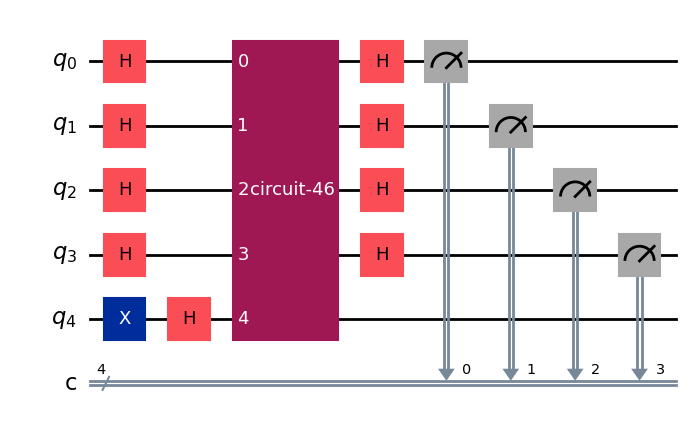

In [3]:
# Test const 0 oracle
n = 4

oracle_zero = const_oracle_zero(n)

dj_zero = dj_circuit(oracle_zero, n)

dj_zero.draw('mpl')

In [4]:
compiled_zero = transpile(dj_zero, simulator)

job_zero = simulator.run(compiled_zero, shots=1024)

result_zero = job_zero.result()

counts_zero = result_zero.get_counts()

print(counts_zero)

{'0000': 1024}


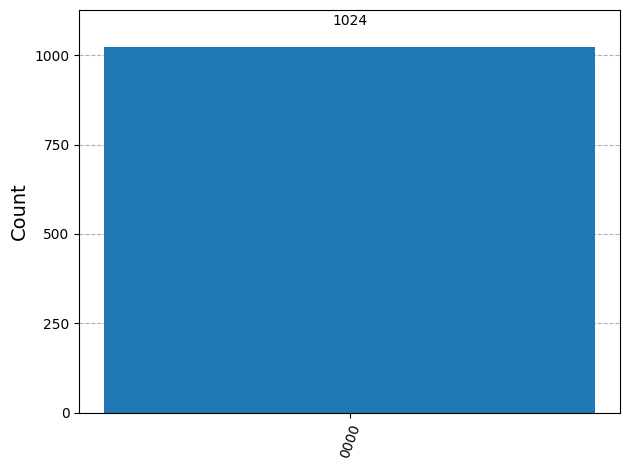

In [5]:
plot_histogram(counts_zero)